# 01 â€” LV Scar Exploration

**Focus:** Core Zone (CZ) only.  
The CZ is the dense fibrotic core; its negative mask approximates the Border Zone and conduction channels.

**Pipeline**
1. Scan dataset â†’ keep only cases that have a `Core Surface.vtk`
2. 80 / 20 split â†’ *Known* set (working set) and *Held-out* set (untouched)
3. **3-D visualisation** of the Known set â€” overlayed population view + per-patient grid
4. **2-D cylindrical polar projection** â€” individual bull's-eye maps + superposition
5. **ISOMAP shape analysis** â€” connectivity-aware per-scar shape embedding

## 0 Â· Imports & config

In [1]:
import json, random, sys
from dataclasses import dataclass, field
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pyvista as pv
from scipy.spatial.distance import cdist
from sklearn.manifold import Isomap
from tqdm import tqdm

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
from data_loading import scan, diagnose, PatientCase

# ── config ──────────────────────────────────────────────────────────────────────────────
HD_ROOT          = r"F:/RM_TEKNON_DEVELOP"
SEED             = 42
TRAIN_RATIO      = 0.80
N_R              = 64
N_THETA          = 128
GRID3D_MAX       = 24
ISOMAP_PTS       = 800
ISOMAP_K         = 10
MIN_VERTS_ISOMAP = 5      # lowered: fragments with >= 5 vertices get embedded

RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

pv.set_jupyter_backend("static")
plt.rcParams["figure.dpi"] = 120


## 1 Â· Scan & filter

In [2]:
all_cases = scan(HD_ROOT)
valid = [
    c for c in all_cases
    if c.tissue_surfaces.get("core") is not None
    and c.tissue_surfaces["core"].exists()
]
print(f"Total scanned: {len(all_cases)}   |   with CZ: {len(valid)}")
for yr, n in sorted(Counter(c.year for c in valid).items()):
    print(f"  {yr}: {n}")

Total scanned: 121   |   with CZ: 13
  2021: 12
  2022: 1


In [ ]:
# ── Diagnostic: inspect actual TISSUE filenames for the first few cases ──
# Run this if the CZ count looks wrong. It prints exactly what files
# are on disk so you can check whether the glob patterns match.
for case in all_cases[:3]:
    diagnose(case)


## 2 Â· 80 / 20 split

In [3]:
random.seed(SEED)
shuffled  = random.sample(valid, len(valid))
n_known   = int(len(shuffled) * TRAIN_RATIO)
known     = shuffled[:n_known]
held_out  = shuffled[n_known:]

(RESULTS / "split.json").write_text(json.dumps({
    "seed": SEED, "train_ratio": TRAIN_RATIO,
    "known":    [f"{c.year}/{c.patient_id}" for c in known],
    "held_out": [f"{c.year}/{c.patient_id}" for c in held_out],
}, indent=2))
print(f"Known: {len(known)}   Held-out: {len(held_out)}   â†’ results/split.json")

Known: 10   Held-out: 3   â†’ results/split.json


---
## 3 Â· 3-D visualisation

Each render shows **two meshes stacked**:
- **Myocardium** (or best available LV shell) â€” semi-transparent gray â†’ anatomical context
- **Core Zone** â€” opaque red â†’ the scar, visible *inside* the shell

Two views:
- **3a** â€” all Known patients overlayed in one scene (population footprint)
- **3b** â€” one thumbnail per patient (individual inspection)

In [4]:
def _best_shell(case: PatientCase):
    """Load the most complete LV shell available, or None.
    Priority: Left Ventricle > Myocardium > Endo > Epi
    """
    for key in ("lv", "myocardium", "endo", "epi"):
        p = case.anatomy.get(key)
        if p is not None and p.exists():
            return pv.read(str(p))
    return None


### 3a â€” Overlayed population view

3-D overlay: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 10/10 [00:01<00:00,  8.18it/s]


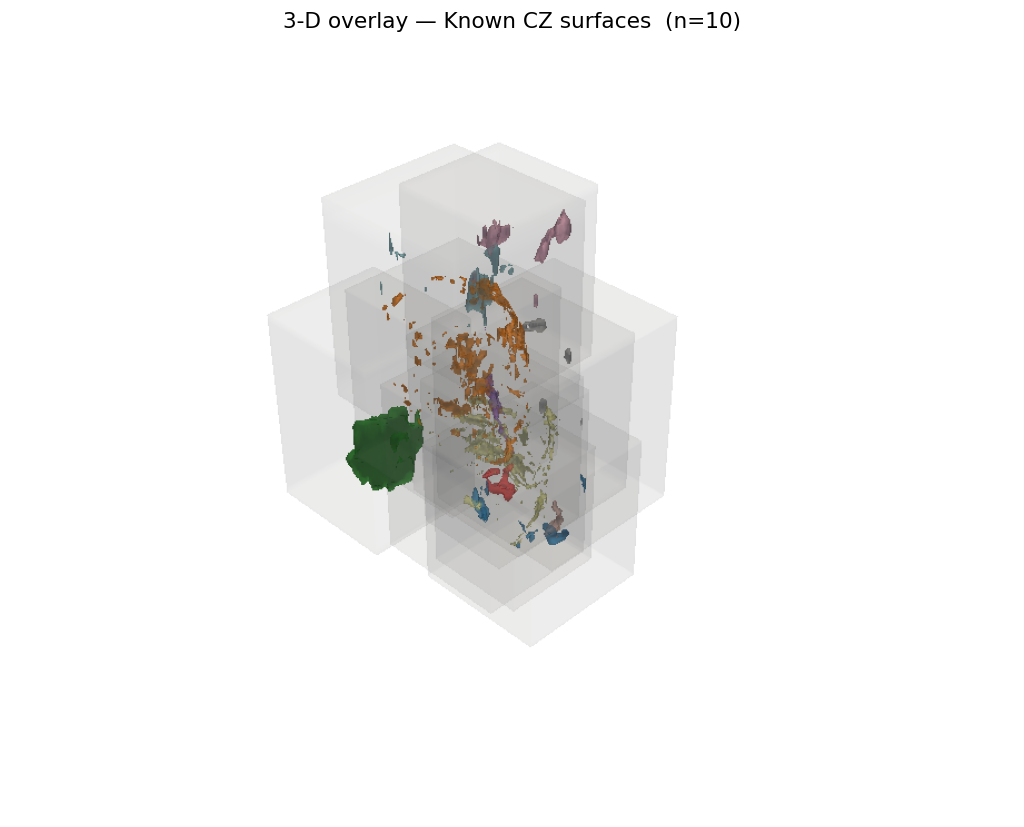

In [5]:
cmap_pop = plt.get_cmap("tab20", len(known))
pl = pv.Plotter(off_screen=True, window_size=(900, 700))
pl.set_background("white")

ok_3d = []
for i, case in enumerate(tqdm(known, desc="3-D overlay")):
    try:
        shell = _best_shell(case)
        cz    = pv.read(str(case.tissue_surfaces["core"]))
        if shell is not None:
            pl.add_mesh(shell, color="lightgray", opacity=0.08,
                        smooth_shading=True, show_scalar_bar=False)
        pl.add_mesh(cz, color=cmap_pop(i)[:3], opacity=0.75,
                    smooth_shading=True, show_scalar_bar=False)
        ok_3d.append(case)
    except Exception as e:
        print(f"  skip {case.year}/{case.patient_id}: {e}")

pl.view_isometric()
img_overlay = pl.screenshot(None, return_img=True)
pl.close()

fig, ax = plt.subplots(figsize=(9, 7))
ax.imshow(img_overlay); ax.axis("off")
ax.set_title(f"3-D overlay â€” Known CZ surfaces  (n={len(ok_3d)})", fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS / "3d_overlay_known.png", bbox_inches="tight")
plt.show()

### 3b â€” Per-patient 3-D grid

3-D grid renders: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 10/10 [00:04<00:00,  2.08it/s]


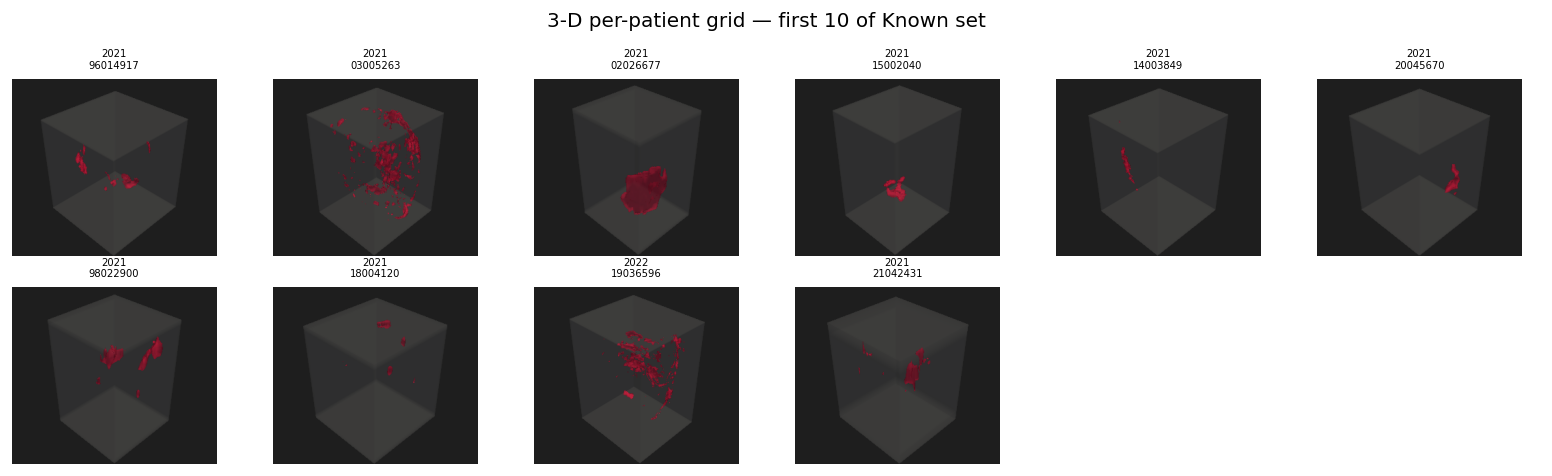

In [6]:
subset   = known[:GRID3D_MAX]
ncols_3d = 6
nrows_3d = int(np.ceil(len(subset) / ncols_3d))

thumbnails = []
for case in tqdm(subset, desc="3-D grid renders"):
    try:
        pl = pv.Plotter(off_screen=True, window_size=(300, 260))
        pl.set_background("#1e1e1e")
        shell = _best_shell(case)
        cz    = pv.read(str(case.tissue_surfaces["core"]))
        if shell is not None:
            pl.add_mesh(shell, color="lightgray", opacity=0.15,
                        smooth_shading=True, show_scalar_bar=False)
        pl.add_mesh(cz, color="crimson", opacity=0.95,
                    smooth_shading=True, show_scalar_bar=False)
        pl.view_isometric()
        thumbnails.append((case, pl.screenshot(None, return_img=True)))
        pl.close()
    except Exception as e:
        print(f"  skip {case.year}/{case.patient_id}: {e}")

fig, axes = plt.subplots(nrows_3d, ncols_3d,
                         figsize=(ncols_3d * 2.2, nrows_3d * 2))
fig.suptitle(f"3-D per-patient grid â€” first {len(thumbnails)} of Known set", fontsize=12)
axes_flat = axes.flatten()
for ax in axes_flat:
    ax.axis("off")
for ax, (case, img) in zip(axes_flat, thumbnails):
    ax.imshow(img)
    ax.set_title(f"{case.year}\n{case.patient_id}", fontsize=6)
plt.tight_layout()
plt.savefig(RESULTS / "3d_grid_known.png", bbox_inches="tight")
plt.show()

---
## 4 Â· 2-D cylindrical polar projection

### How the projection works â€” step by step

The LV is a thick-walled elongated shape. The CZ lives inside the wall.  
We want to represent it on a flat circle to compare patients.

**Step 1 â€” Find the long axis of the LV (PCA on the LV shell)**  
PCA on all LV shell vertices finds the direction of maximum spread = apex-to-base axis.  
We use the full shell (not the CZ) because the scar fragment alone gives an unstable axis.

**Step 2 â€” Two numbers per CZ vertex**

| Coordinate | Computation | Meaning |
|---|---|---|
| `s` | dot product of `(point âˆ’ apex)` with axis, normalised 0â†’1 | 0 = apex, 1 = base |
| `Î¸` | `atan2` of the perpendicular component | clock-position around the wall |

**Step 3 â€” Rasterise** into an `(N_R Ã— N_THETA)` binary grid.  
**Step 4 â€” Plot as bull's-eye** (apex at centre, base at outer ring).

**Known limitation â€” apex singularity**  
The apex dome is tiny in 3-D but occupies the full inner disc.  
Apical scars appear artificially spread â†’ use ISOMAP (Section 5) for shape analysis.

In [7]:
def _long_axis(mesh: pv.PolyData):
    pts    = np.array(mesh.points)
    center = pts.mean(axis=0)
    _, _, Vt = np.linalg.svd(pts - center, full_matrices=False)
    axis   = Vt[0]
    proj   = (pts - center) @ axis
    apex   = pts[proj.argmin()]
    if np.dot(center - apex, axis) < 0:
        axis = -axis
    return axis, apex


def polar_map(case: PatientCase, n_r=N_R, n_theta=N_THETA) -> np.ndarray:
    ref = _best_shell(case)
    if ref is None:
        ref = pv.read(str(case.tissue_surfaces["core"]))
    axis, apex = _long_axis(ref)

    secondary = np.array([0., 0., 1.])
    if abs(np.dot(axis, secondary)) > 0.9:
        secondary = np.array([1., 0., 0.])
    u = np.cross(axis, secondary);  u /= np.linalg.norm(u)
    w = np.cross(axis, u)

    cz    = pv.read(str(case.tissue_surfaces["core"]))
    pts   = np.array(cz.points)
    v     = pts - apex
    s_raw = v @ axis
    span  = s_raw.max() - s_raw.min()
    s     = np.clip((s_raw - s_raw.min()) / (span + 1e-9), 0., 1.)
    perp  = v - np.outer(s_raw, axis)
    theta = np.arctan2(perp @ w, perp @ u) % (2 * np.pi)

    grid = np.zeros((n_r, n_theta), dtype=bool)
    ri   = np.clip((s * n_r).astype(int), 0, n_r - 1)
    ti   = np.clip((theta / (2*np.pi) * n_theta).astype(int), 0, n_theta - 1)
    grid[ri, ti] = True
    return grid


def _draw_bullseye(grid, ax, title="", cmap="Reds", vmax=1.):
    n_r, n_theta = grid.shape
    T, R = np.meshgrid(
        np.linspace(0, 2*np.pi, n_theta + 1),
        np.linspace(0, 1,       n_r     + 1),
    )
    ax.pcolormesh(T, R, grid.astype(float),
                  cmap=cmap, vmin=0, vmax=vmax, shading="flat")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_rticks([]); ax.set_xticks([])
    if title:
        ax.set_title(title, fontsize=7, pad=2)

print("Helpers ready.")

Helpers ready.


### 4a â€” Compute all polar maps

In [8]:
pmaps  = {}
for case in tqdm(known, desc="Polar projection"):
    key = f"{case.year}/{case.patient_id}"
    try:
        pmaps[key] = polar_map(case)
    except Exception as e:
        print(f"  skip {key}: {e}")
print(f"OK: {len(pmaps)}")

Polar projection: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 10/10 [00:02<00:00,  4.59it/s]

OK: 10


### 4b â€” Individual polar maps (per-patient grid)

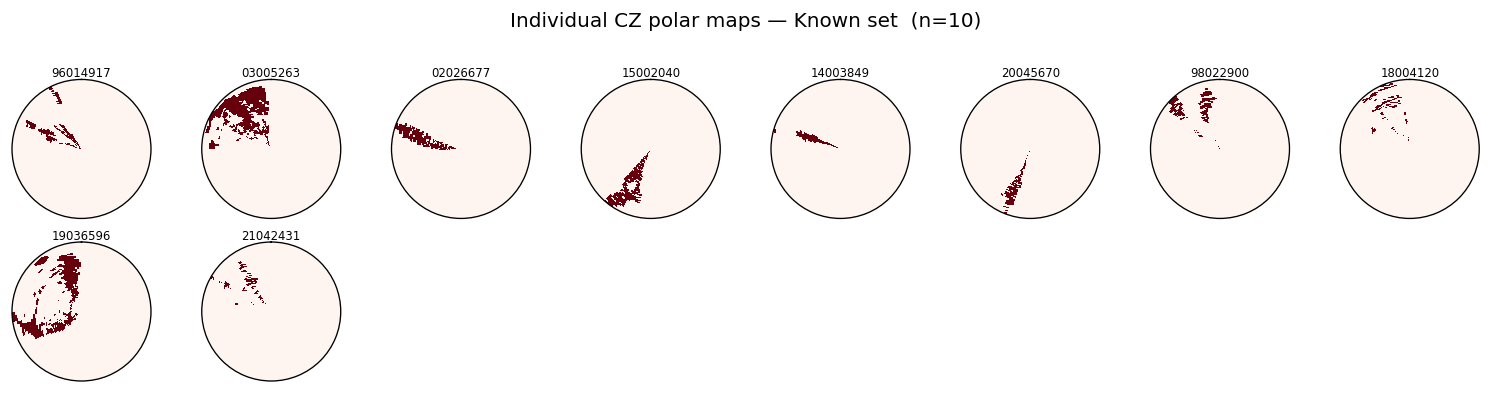

In [9]:
keys  = list(pmaps.keys())
ncols = 8
nrows = int(np.ceil(len(keys) / ncols))
fig   = plt.figure(figsize=(ncols * 1.6, nrows * 1.6))
fig.suptitle(f"Individual CZ polar maps â€” Known set  (n={len(keys)})", fontsize=12, y=1.01)
for idx, key in enumerate(keys):
    ax = fig.add_subplot(nrows, ncols, idx + 1, projection="polar")
    _draw_bullseye(pmaps[key], ax, title=key.split("/")[1])
for idx in range(len(keys), nrows * ncols):
    fig.add_subplot(nrows, ncols, idx + 1).axis("off")
plt.tight_layout()
plt.savefig(RESULTS / "polar_grid_known.png", bbox_inches="tight")
plt.show()

### 4c â€” Superposition: scar density across the cohort

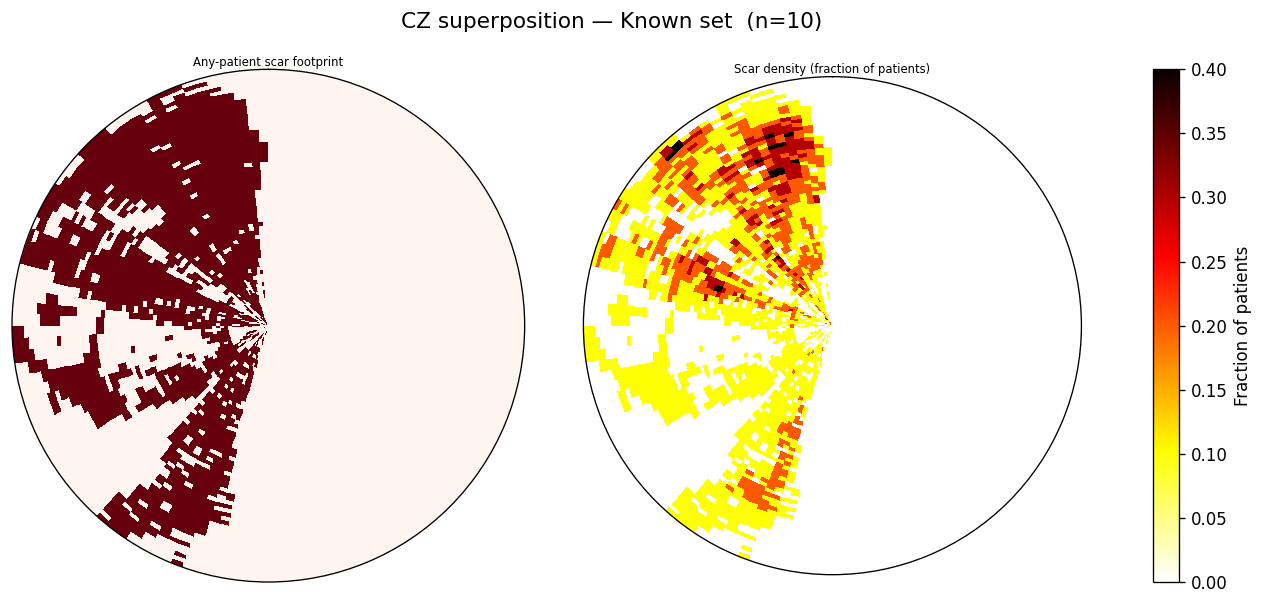

In [10]:
stack   = np.stack(list(pmaps.values()))
density = stack.mean(axis=0)

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 5),
                                  subplot_kw={"projection": "polar"})
fig.suptitle(f"CZ superposition â€” Known set  (n={len(pmaps)})", fontsize=13)
_draw_bullseye(density > 0, ax_l, title="Any-patient scar footprint")
_draw_bullseye(density, ax_r, title="Scar density (fraction of patients)",
               cmap="hot_r", vmax=density.max())
sm = plt.cm.ScalarMappable(cmap="hot_r", norm=plt.Normalize(0, density.max()))
sm.set_array([])
fig.colorbar(sm, ax=ax_r, pad=0.12, fraction=0.046, label="Fraction of patients")
plt.tight_layout()
plt.savefig(RESULTS / "polar_superposition_known.png", bbox_inches="tight")
plt.show()

---
## 5 Â· ISOMAP â€” connectivity-aware shape analysis

### Strategy

Before running ISOMAP we check whether the CZ is a **single solid piece** or
**multiple disconnected fragments** (sub-scars). The two cases are handled differently:

| Situation | Action |
|---|---|
| 1 fragment | ISOMAP on all vertices â†’ one 2-D shape embedding |
| N fragments | ISOMAP on **each fragment separately** + fragmentation features |

### Why run ISOMAP per fragment?

If we fed all fragments together into one ISOMAP, the geodesic distances between
islands would be `âˆž` (no path along the surface connects them).
The MDS step would then receive a corrupted distance matrix and produce a meaningless
embedding. Running ISOMAP on each fragment independently avoids this.

Fragments with fewer than `MIN_VERTS_ISOMAP` vertices are too small to produce a
reliable surface embedding â€” they are counted and measured but not embedded.

> **Future note:** very small fragments (noise or tiny sub-scars) could be filtered
> out before analysis using an area or vertex-count threshold. For now all fragments
> are kept and reported.

In [11]:
@dataclass
class CZAnalysis:
    key:                  str
    n_fragments:          int
    vertex_counts:        list   # vertices per fragment, sorted descending
    largest_fraction:     float  # largest fragment / total vertices
    centroids:            np.ndarray   # (n_fragments, 3) world-space
    centroid_dist_matrix: np.ndarray   # (n_fragments, n_fragments) pairwise mm
    embeddings:           list   # one np.ndarray (or None) per fragment

    @property
    def is_compact(self) -> bool:
        return self.n_fragments == 1


def _run_isomap(pts: np.ndarray, k: int = ISOMAP_K,
                n_pts: int = ISOMAP_PTS) -> np.ndarray:
    """ISOMAP on a single fragment's vertices. Subsamples if needed."""
    if len(pts) > n_pts:
        idx = np.random.default_rng(SEED).choice(len(pts), n_pts, replace=False)
        pts = pts[idx]
    k_actual = min(k, len(pts) - 1)   # can't have more neighbours than points
    return Isomap(n_neighbors=k_actual, n_components=2).fit_transform(pts)


def analyze_cz(case: PatientCase) -> CZAnalysis:
    """
    1. Load CZ mesh.
    2. Detect connected components (fragments).
    3. For each fragment: compute ISOMAP if large enough.
    4. Compute fragmentation features.
    """
    key = f"{case.year}/{case.patient_id}"
    cz  = pv.read(str(case.tissue_surfaces["core"]))

    # â”€â”€ connectivity â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    labeled    = cz.connectivity(largest=False)   # adds "RegionId" point array
    n_frags    = int(labeled["RegionId"].max()) + 1
    region_ids = np.array(labeled["RegionId"])
    all_pts    = np.array(labeled.points)

    # â”€â”€ per-fragment analysis â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    # sort fragments by size (largest first)
    frag_indices = sorted(
        range(n_frags),
        key=lambda i: np.sum(region_ids == i),
        reverse=True,
    )

    vertex_counts = []
    centroids     = []
    embeddings    = []

    for fid in frag_indices:
        mask = region_ids == fid
        pts  = all_pts[mask]
        vertex_counts.append(len(pts))
        centroids.append(pts.mean(axis=0))

        if len(pts) >= MIN_VERTS_ISOMAP:
            try:
                embeddings.append(_run_isomap(pts))
            except Exception as e:
                print(f"    ISOMAP failed for fragment of {key}: {e}")
                embeddings.append(None)
        else:
            embeddings.append(None)   # too small â€” counted but not embedded

    centroids = np.array(centroids)
    dist_mat  = cdist(centroids, centroids) if len(centroids) > 1 else np.zeros((1, 1))
    largest_fraction = vertex_counts[0] / sum(vertex_counts)

    return CZAnalysis(
        key=key,
        n_fragments=n_frags,
        vertex_counts=vertex_counts,
        largest_fraction=largest_fraction,
        centroids=centroids,
        centroid_dist_matrix=dist_mat,
        embeddings=embeddings,
    )

print("CZAnalysis helpers ready.")

CZAnalysis helpers ready.


### 5a â€” Run analysis on Known set

In [12]:
analyses = {}
for case in tqdm(known, desc="ISOMAP analysis"):
    key = f"{case.year}/{case.patient_id}"
    try:
        analyses[key] = analyze_cz(case)
    except Exception as e:
        print(f"  skip {key}: {e}")

compact    = [a for a in analyses.values() if a.is_compact]
fragmented = [a for a in analyses.values() if not a.is_compact]
print(f"\nTotal analysed : {len(analyses)}")
print(f"Compact  (1 fragment)  : {len(compact)}")
print(f"Fragmented (>1 fragment): {len(fragmented)}")

ISOMAP analysis:  20%|â–ˆâ–ˆ        | 2/10 [00:00<00:00, 16.30it/s]

  skip 2021/96014917: boolean index did not match indexed array along axis 0; size of axis is 1942 but size of corresponding boolean axis is 3776
  skip 2021/03005263: boolean index did not match indexed array along axis 0; size of axis is 9742 but size of corresponding boolean axis is 18424
  skip 2021/02026677: boolean index did not match indexed array along axis 0; size of axis is 1980 but size of corresponding boolean axis is 3944
  skip 2021/15002040: boolean index did not match indexed array along axis 0; size of axis is 1656 but size of corresponding boolean axis is 3316


ISOMAP analysis:  60%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ    | 6/10 [00:00<00:00, 28.60it/s]

  skip 2021/14003849: boolean index did not match indexed array along axis 0; size of axis is 1473 but size of corresponding boolean axis is 2892
  skip 2021/20045670: boolean index did not match indexed array along axis 0; size of axis is 716 but size of corresponding boolean axis is 1416


ISOMAP analysis: 100%|â–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆâ–ˆ| 10/10 [00:00<00:00, 28.64it/s]

  skip 2021/98022900: boolean index did not match indexed array along axis 0; size of axis is 712 but size of corresponding boolean axis is 1384
  skip 2021/18004120: boolean index did not match indexed array along axis 0; size of axis is 204 but size of corresponding boolean axis is 376
  skip 2022/19036596: boolean index did not match indexed array along axis 0; size of axis is 10014 but size of corresponding boolean axis is 19008
  skip 2021/21042431: boolean index did not match indexed array along axis 0; size of axis is 334 but size of corresponding boolean axis is 600

Total analysed : 0
Compact  (1 fragment)  : 0
Fragmented (>1 fragment): 0


### 5b â€” ISOMAP embedding grid

Each subplot shows one patient's CZ.  
- **Single fragment** â†’ one colour (crimson)  
- **Multiple fragments** â†’ each fragment a different colour, sorted largest â†’ smallest  
- Fragments too small to embed (`< MIN_VERTS_ISOMAP` vertices) are shown as a single âœ• marker  
- Title shows patient ID and number of fragments

In [13]:
FRAG_CMAP = plt.get_cmap("tab10")

def _plot_isomap_cell(ax, analysis: CZAnalysis):
    """Draw all fragment embeddings for one patient onto ax."""
    has_any_data = False
    for fi, (emb, count) in enumerate(zip(analysis.embeddings, analysis.vertex_counts)):
        color = "crimson" if analysis.is_compact else FRAG_CMAP(fi % 10)
        if emb is not None and len(emb) > 0:
            ax.scatter(emb[:, 0], emb[:, 1],
                       s=1, c=[color], alpha=0.6, linewidths=0)
            has_any_data = True
        else:
            # fragment too small: mark with an x at origin
            ax.scatter([0], [0], marker="x", s=20, c=[color], linewidths=1)
            has_any_data = True
    n   = analysis.n_fragments
    pid = analysis.key.split("/")[1]
    ax.set_title(f"{pid}
{n}f" if n > 1 else pid, fontsize=6, pad=1)
    ax.set_xticks([]); ax.set_yticks([])
    if has_any_data:
        try:
            ax.set_aspect("equal", adjustable="datalim")
        except Exception:
            pass
    border_color = "orange" if not analysis.is_compact else "#888888"
    for sp in ax.spines.values():
        sp.set_linewidth(0.5)
        sp.set_color(border_color)


if not analyses:
    print("No analyses available — check that the scan found CZ cases.")
else:
    ikeys = list(analyses.keys())
    ncols = 8
    nrows = int(np.ceil(len(ikeys) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 1.8, nrows * 1.8))
    fig.suptitle(
        f"ISOMAP shape embeddings — Known CZ  (n={len(ikeys)})
"
        f"gray border = compact · orange border = fragmented",
        fontsize=11, y=1.01
    )
    axes_flat = axes.flatten() if nrows * ncols > 1 else [axes]
    for ax in axes_flat:
        ax.axis("off")
    for ax, key in zip(axes_flat, ikeys):
        ax.axis("on")
        _plot_isomap_cell(ax, analyses[key])

    plt.tight_layout()
    plt.savefig(RESULTS / "isomap_grid_known.png", bbox_inches="tight")
    plt.show()


ValueError: Number of rows must be a positive integer, not 0

<Figure size 1728x0 with 0 Axes>

### 5c â€” Fragmentation summary across the cohort

In [ ]:
n_frags_all        = [a.n_fragments      for a in analyses.values()]
largest_frac_all   = [a.largest_fraction for a in analyses.values()]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("CZ fragmentation â€” Known set", fontsize=13)

# â”€â”€ left: histogram of fragment count â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ax = axes[0]
max_frags = max(n_frags_all)
ax.hist(n_frags_all, bins=range(1, max_frags + 2), align="left",
        color="steelblue", edgecolor="white", rwidth=0.8)
ax.set_xlabel("Number of fragments")
ax.set_ylabel("Patients")
ax.set_title("Fragment count distribution")
ax.axvline(1.5, color="orange", lw=1.5, ls="--", label="compact / fragmented")
ax.legend(fontsize=8)

# â”€â”€ middle: histogram of largest-fragment fraction â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ax = axes[1]
ax.hist(largest_frac_all, bins=20, color="crimson", edgecolor="white", alpha=0.8)
ax.set_xlabel("Largest fragment / total vertices")
ax.set_ylabel("Patients")
ax.set_title("Compactness  (1.0 = single solid scar)")

# â”€â”€ right: top-10 most fragmented â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
ax = axes[2]
top10 = sorted(analyses.values(), key=lambda a: a.n_fragments, reverse=True)[:10]
labels = [a.key.split("/")[1] for a in top10]
counts = [a.n_fragments         for a in top10]
bars   = ax.barh(labels[::-1], counts[::-1], color="darkorange", edgecolor="white")
ax.set_xlabel("Number of fragments")
ax.set_title("Top-10 most fragmented")
for bar, val in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS / "fragmentation_summary.png", bbox_inches="tight")
plt.show()

print(f"Median fragments per patient : {np.median(n_frags_all):.0f}")
print(f"Max fragments in one patient : {max(n_frags_all)}")
print(f"Patients with a single compact CZ: {sum(1 for n in n_frags_all if n == 1)}")

---
## Summary of outputs

| File | Content |
|---|---|
| `results/split.json` | Frozen Known / Held-out patient lists |
| `results/3d_overlay_known.png` | All Known CZ surfaces overlayed in 3-D |
| `results/3d_grid_known.png` | Per-patient 3-D thumbnails (first `GRID3D_MAX`) |
| `results/polar_grid_known.png` | Individual 2-D bull's-eye per patient |
| `results/polar_superposition_known.png` | Population scar density map |
| `results/isomap_grid_known.png` | Per-scar ISOMAP embedding (colour-coded by fragment) |
| `results/fragmentation_summary.png` | Fragment count distribution + compactness + top-10 |